In [58]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from keras import datasets, Model, layers

In [6]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

In [7]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [20]:
noise_train = np.random.normal(loc=0, scale=0.6, size=x_train.shape)
noise_test = np.random.normal(loc=0, scale=0.6, size=x_test.shape)

In [21]:
x_train_noisy = x_train + 0.5*noise_train
x_test_noisy = x_test + 0.5*noise_test

x_train_noisy = np.clip(x_train_noisy, 0, 1)
x_test_noisy = np.clip(x_test_noisy, 0, 1)

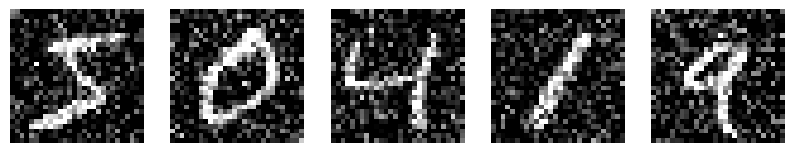

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train_noisy[i], cmap='gray')
    ax.set_axis_off()

In [45]:
# Noisy Inputs
x_train_noisy_mlp = x_train_noisy.reshape(-1, 784)
x_test_noisy_mlp = x_test_noisy.reshape(-1, 784)

x_train_noisy_cnn = x_train_noisy.reshape(-1, 28, 28, 1)
x_test_noisy_cnn = x_test_noisy.reshape(-1, 28, 28, 1)

# Desired Outputs
x_train_clean_mlp = x_train.reshape(-1, 784)
x_test_clean_mlp = x_test.reshape(-1, 784)

x_train_clean_cnn = x_train
x_test_clean_cnn = x_test

## MLP Auto-encoder

In [30]:
inp = layers.Input(shape=(784,))
encoder_layer = layers.Dense(16, activation='relu')(inp)
decoder_layer = layers.Dense(784, activation='sigmoid')(encoder_layer)
autoencoder_mlp = Model(inp, decoder_layer)
autoencoder_mlp.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │        13,328 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,888 (101.12 KB)

 Trainable params: 25,888 (101.12 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
autoencoder_mlp.compile(optimizer='adam', loss='binary_crossentropy',
                        metrics=['mae'])
start = time.time()
history_mlp = autoencoder_mlp.fit(x_train_noisy_mlp, x_train_clean_mlp,
                                  epochs=30, batch_size=256,
                                  validation_split=0.2, verbose=0)
elapsed = time.time() - start
print(f'Training Time (MLP): {elapsed:.2f}s')

I0000 00:00:1781789073.311101    2105 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31254__.7
I0000 00:00:1781789074.710257    2106 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31254__.7


Training Time (MLP): 32.05s


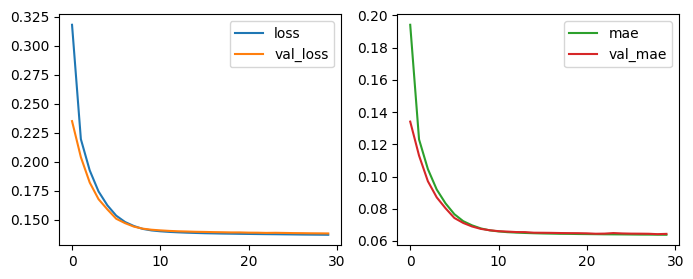

In [36]:
hist_mlp_df = pd.DataFrame(history_mlp.history)
hist_mlp_df[['loss', 'val_loss', 'mae', 'val_mae']].plot(
    subplots=[('loss', 'val_loss'), ('mae', 'val_mae')],
    layout=(1, 2), figsize=(8,3))
plt.show()

## CNN Auto-encoder

In [47]:
inp = layers.Input(shape=(28, 28, 1))
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inp)
x = layers.MaxPool2D()(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
encoder_layer_cnn = layers.MaxPool2D()(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(encoder_layer_cnn)
x = layers.UpSampling2D()(x)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D()(x)
decoder_layer_cnn = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
autoencoder_cnn = Model(inp, decoder_layer_cnn)
autoencoder_cnn.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,817 (73.50 KB)

 Trainable params: 18,817 (73.50 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
autoencoder_cnn.compile(optimizer='adam', loss='binary_crossentropy',
                        metrics=['mae'])
start = time.time()
history_cnn = autoencoder_cnn.fit(x_train_noisy_cnn, x_train_clean_cnn,
                                  epochs=30, batch_size=256,
                                  validation_split=0.2, verbose=0)
elapsed = time.time() - start
print(f'Training Time (CNN): {elapsed:.2f}s')

Training Time (CNN): 72.39s


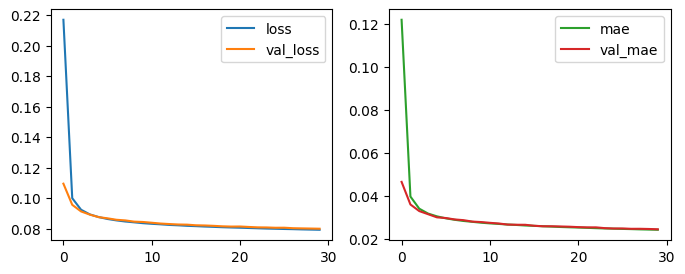

In [49]:
hist_cnn_df = pd.DataFrame(history_cnn.history)
hist_cnn_df[['loss', 'val_loss', 'mae', 'val_mae']].plot(
    subplots=[('loss', 'val_loss'), ('mae', 'val_mae')],
    layout=(1, 2), figsize=(8,3))
plt.show()

## Prediction and Visualization

In [37]:
preds_mlp = autoencoder_mlp.predict(x_test_noisy_mlp)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [50]:
preds_cnn = autoencoder_cnn.predict(x_test_noisy_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [38]:
encoder_model_mlp = Model(inp, encoder_layer)
encoder_model_mlp.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │        12,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,560 (49.06 KB)

 Trainable params: 12,560 (49.06 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
encoder_model_cnn = Model(inp, encoder_layer_cnn)
encoder_model_cnn.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,800 (18.75 KB)

 Trainable params: 4,800 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
encoded_images_mlp = encoder_model.predict(x_test_noisy_mlp)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [52]:
encoded_images_cnn = encoder_model_cnn.predict(x_test_noisy_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [53]:
print('MLP feature vector shape:', encoded_images_mlp.shape)
print('CNN feature vector shape:', encoded_images_cnn.shape)

MLP feature vector shape: (10000, 16)
CNN feature vector shape: (10000, 7, 7, 32)


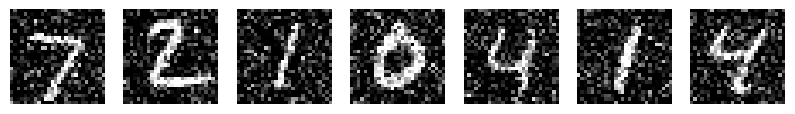

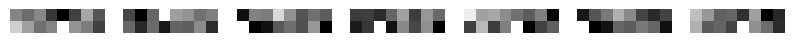

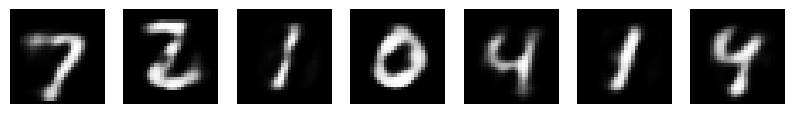

In [44]:
fig, axes = plt.subplots(1, 7, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_test_noisy[i], cmap='gray')
    ax.set_axis_off()

fig, axes = plt.subplots(1, 7, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(encoded_images_mlp[i].reshape(2, 8), cmap='gray')
    ax.set_axis_off()

fig, axes = plt.subplots(1, 7, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(preds_mlp[i].reshape(28, 28), cmap='gray')
    ax.set_axis_off()

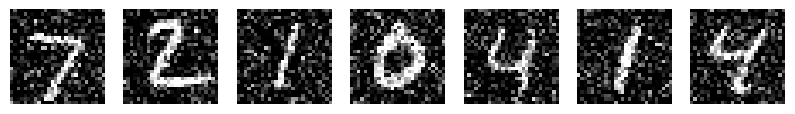

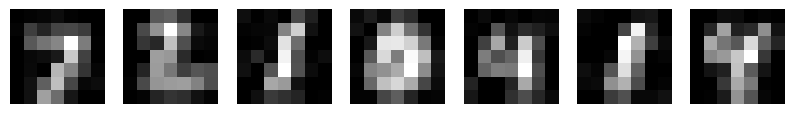

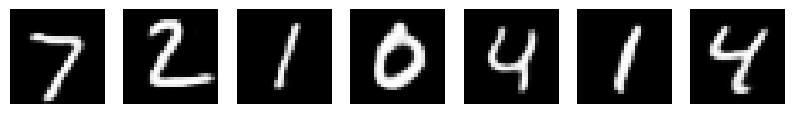

In [57]:
fig, axes = plt.subplots(1, 7, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_test_noisy[i], cmap='gray')
    ax.set_axis_off()

fig, axes = plt.subplots(1, 7, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(encoded_images_cnn[i][:,:,17], cmap='gray')
    ax.set_axis_off()

fig, axes = plt.subplots(1, 7, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(preds_cnn[i], cmap='gray')
    ax.set_axis_off()

# UMAP visualizations

In [59]:
encoded_cnn_flat = encoded_images_cnn.reshape(len(encoded_images_cnn), -1)
print(encoded_cnn_flat.shape)

(10000, 1568)


In [60]:
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_mlp = reducer.fit_transform(encoded_images_mlp)
embedding_cnn = reducer.fit_transform(encoded_cnn_flat)

/home/saeed/a/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [61]:
print('MLP embedding shape:', embedding_mlp.shape)
print('CNN embedding shape:', embedding_cnn.shape)

MLP embedding shape: (10000, 2)
CNN embedding shape: (10000, 2)


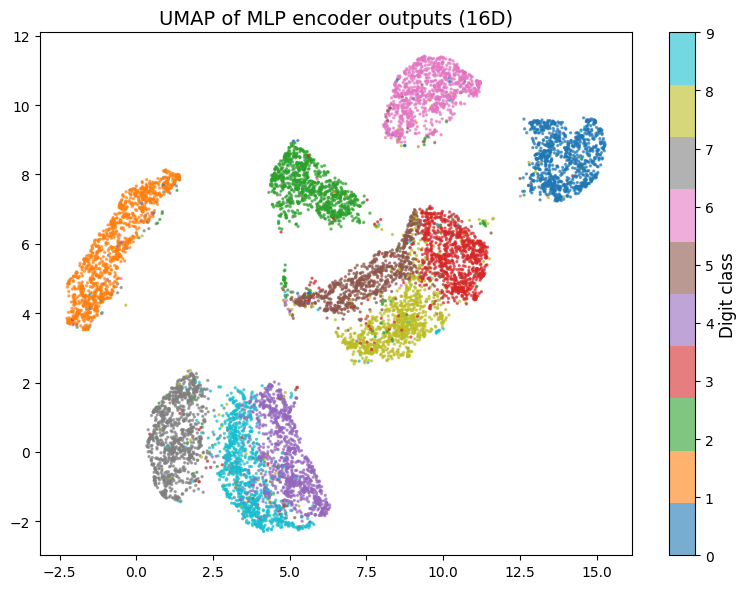

In [63]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(embedding_mlp[:, 0], embedding_mlp[:, 1],
                     c=y_test, cmap='tab10', s=2, alpha=0.6)
cbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit class', fontsize=12)
cbar.set_ticklabels(range(10))
ax.set_title('UMAP of MLP encoder outputs (16D)', fontsize=14)
plt.tight_layout()
plt.show()

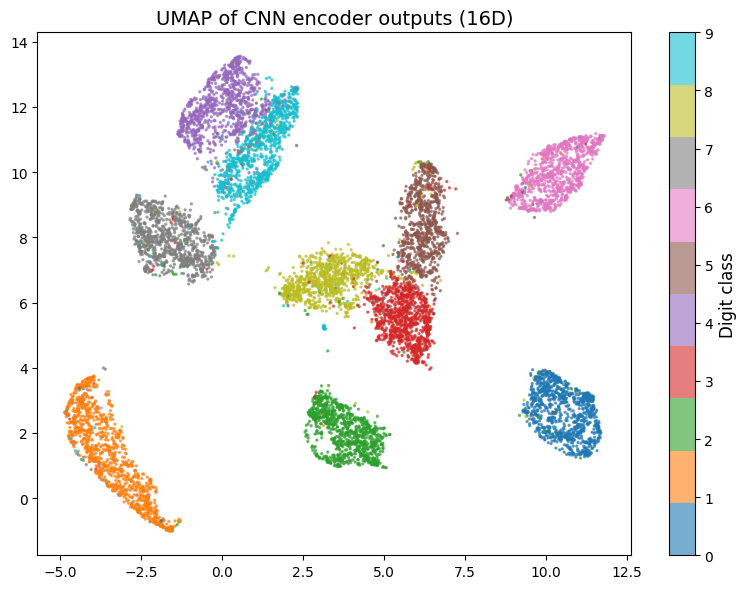

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(embedding_cnn[:, 0], embedding_cnn[:, 1],
                     c=y_test, cmap='tab10', s=2, alpha=0.6)
cbar = fig.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit class', fontsize=12)
cbar.set_ticklabels(range(10))
ax.set_title('UMAP of CNN encoder outputs (16D)', fontsize=14)
plt.tight_layout()
plt.show()

## Save TSV files for Tensorflow Projector

In [65]:
# --- save vectors.tsv ---
np.savetxt('vectors_mlp.tsv', encoded_images_mlp, delimiter='\t')
np.savetxt('vectors_cnn.tsv', encoded_cnn_flat, delimiter='\t')

# --- save metadata.tsv ---
# Single label column — projector picks it up automatically
np.savetxt('metadata.tsv', y_test, fmt='%d', header='label', comments='')